**Reference of this work:**

https://www.sciencedirect.com/science/article/pii/S1877050921014629?via%3Dihub

# Data

## Aquisition

source: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

In [1]:
import pandas as pd
from ucimlrepo import fetch_ucirepo 

breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets

data= pd.concat([X, y], axis=1)

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   radius1             569 non-null    float64
 1   texture1            569 non-null    float64
 2   perimeter1          569 non-null    float64
 3   area1               569 non-null    float64
 4   smoothness1         569 non-null    float64
 5   compactness1        569 non-null    float64
 6   concavity1          569 non-null    float64
 7   concave_points1     569 non-null    float64
 8   symmetry1           569 non-null    float64
 9   fractal_dimension1  569 non-null    float64
 10  radius2             569 non-null    float64
 11  texture2            569 non-null    float64
 12  perimeter2          569 non-null    float64
 13  area2               569 non-null    float64
 14  smoothness2         569 non-null    float64
 15  compactness2        569 non-null    float64
 16  concavity2         

## Data Analysis

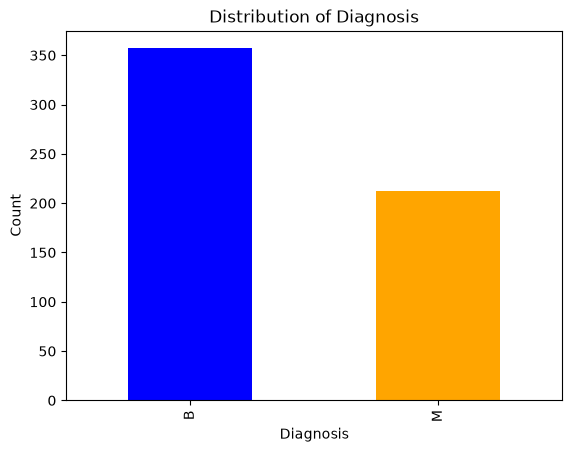

In [2]:
import matplotlib.pyplot as plt

data['Diagnosis'].value_counts().plot(kind='bar', color=['blue', 'orange'])
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.title('Distribution of Diagnosis')
plt.show()

In [3]:
data['Diagnosis'].value_counts()

Diagnosis
B    357
M    212
Name: count, dtype: int64

In [4]:
data_filtered = data[[
    'Diagnosis', 'radius1', 'texture1', 'perimeter1', 'area1', 
    'smoothness1', 'compactness1', 'concavity1', 
    'concave_points1', 'symmetry1', 'fractal_dimension1'
]]

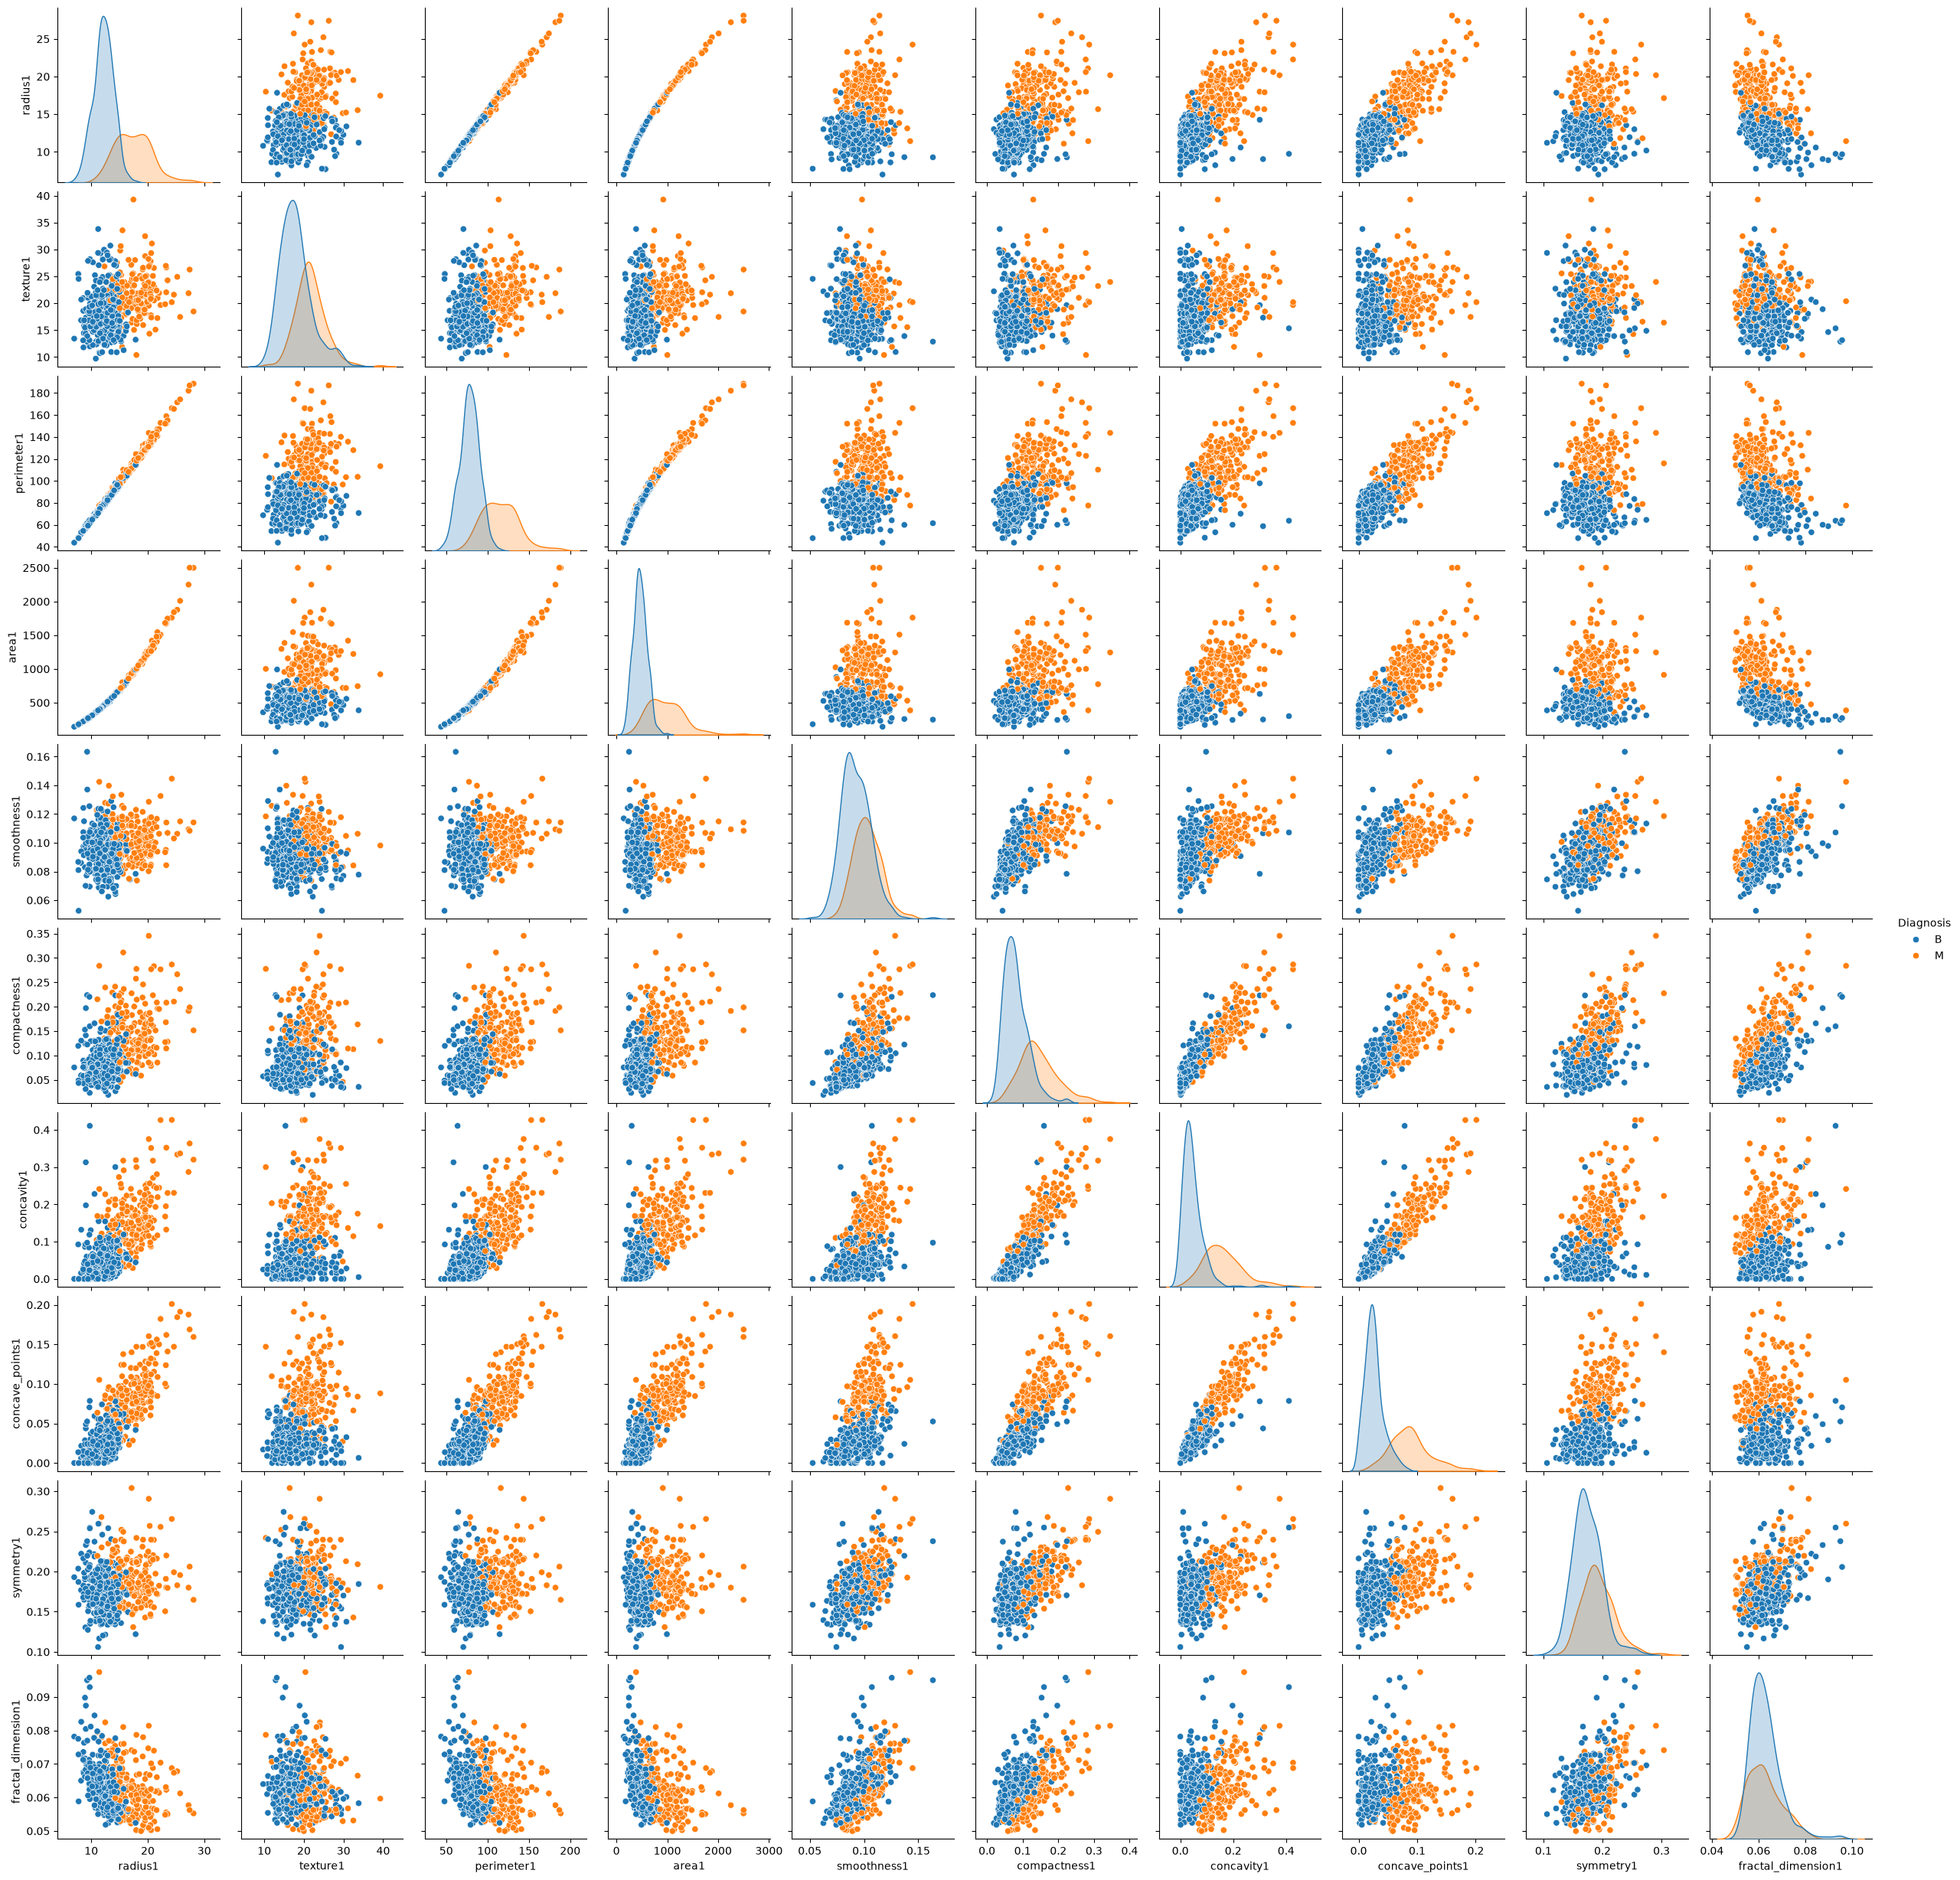

In [5]:
import seaborn as sns
sns.pairplot(data_filtered, hue='Diagnosis', hue_order=['B', 'M'])
plt.show()

In [6]:
data_ml = data_filtered.copy()
data_ml['Diagnosis'] = data_ml['Diagnosis'].map({'B': 0, 'M': 1})
data_ml['Diagnosis'].value_counts()

Diagnosis
0    357
1    212
Name: count, dtype: int64

Text(0.5, 1.0, 'Correlation Matrix')

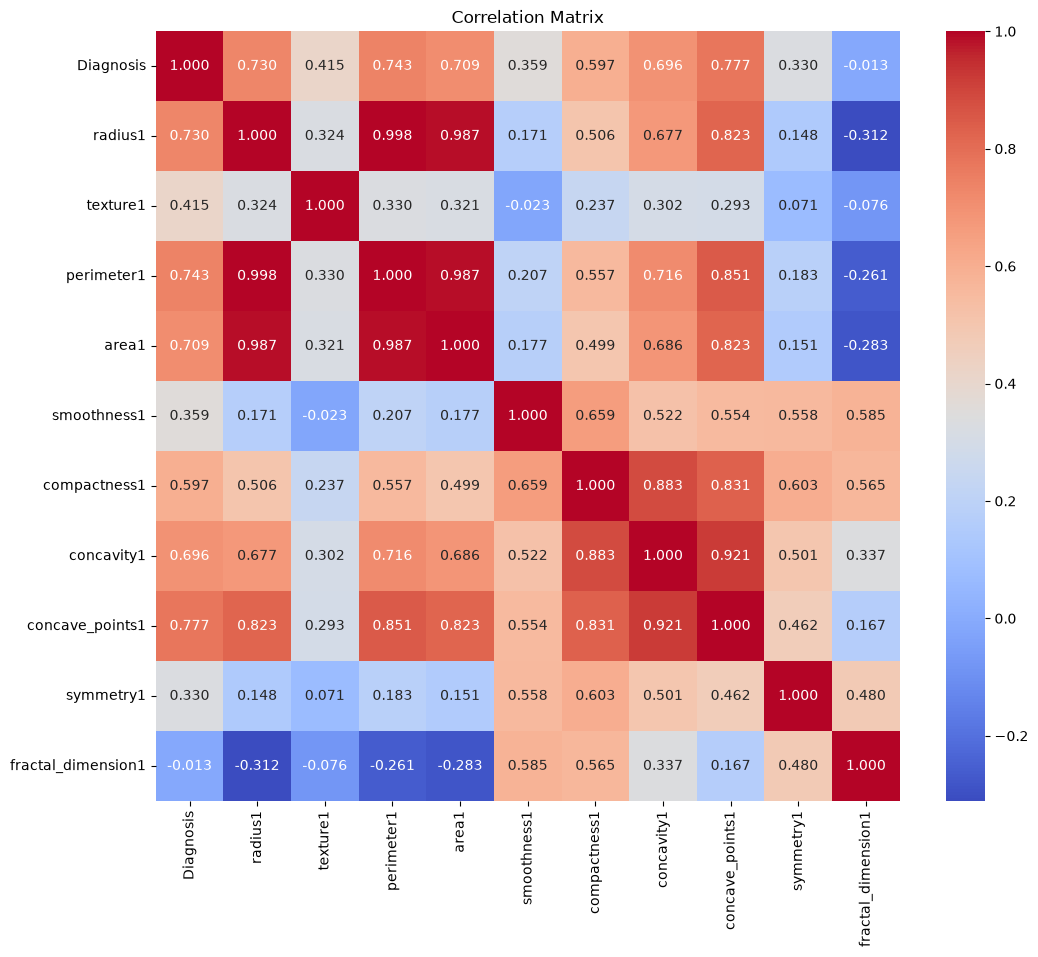

In [7]:
corr_matrix = data_ml.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.3f')
plt.title('Correlation Matrix')

## Data Split

In [8]:
from sklearn.model_selection import train_test_split

X = data_ml.drop(columns=['Diagnosis'])
y = data_ml['Diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Models

In [9]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


def evaluate_model(y_pred, model_name="Model"):
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    especificidade = tn / (tn + fp)
    
    print(f"Evaluating {model_name}:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
    print(f"Precision: {precision_score(y_test, y_pred):.3f}")
    print(f"Recall: {recall_score(y_test, y_pred):.3f}")
    print(f"F1-Score: {f1_score(y_test, y_pred):.3f}")
    print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred):.3f}")
    print(f"Especificidade: {especificidade:.3f}")


def plot_confusion_matrix(y_pred, model_name="Model"):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

## Training

### SVM

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

Evaluating SVM:
Accuracy: 0.972
Precision: 0.981
Recall: 0.944
F1-Score: 0.962
ROC AUC Score: 0.967
Especificidade: 0.989


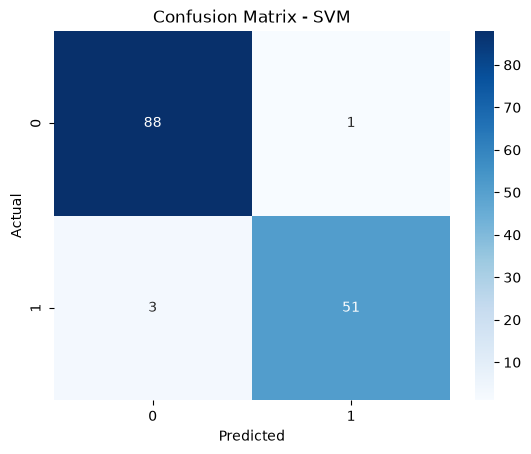

In [11]:
from sklearn.svm import SVC

model_svm = SVC(random_state=42)
model_svm.fit(X_train_scaled, y_train)

y_pred = model_svm.predict(X_test_scaled)

evaluate_model(y_pred, model_name="SVM")
plot_confusion_matrix(y_pred, model_name="SVM")

C:\Users\cecpc\AppData\Local\Temp\ipykernel_15344\54727140.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importancia, palette='viridis')


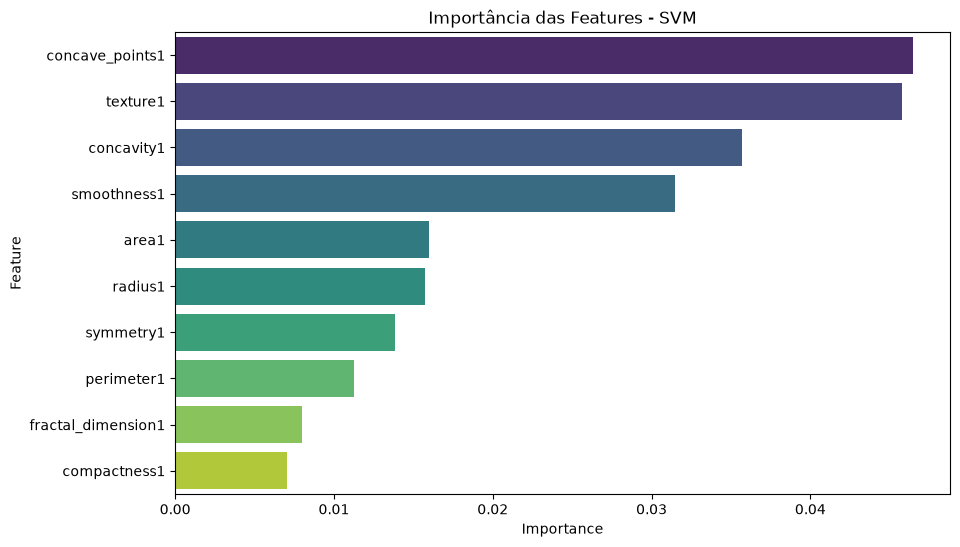

In [23]:
from sklearn.inspection import permutation_importance

resultado = permutation_importance(model_svm, X_train_scaled, y_train, n_repeats=10, random_state=42)
importancia = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': resultado.importances_mean
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importancia, palette='viridis')
plt.title('Importância das Features - SVM')
plt.show()

### Random Forest

Evaluating Random Forest:
Accuracy: 0.958
Precision: 0.929
Recall: 0.963
F1-Score: 0.945
ROC AUC Score: 0.959
Especificidade: 0.955


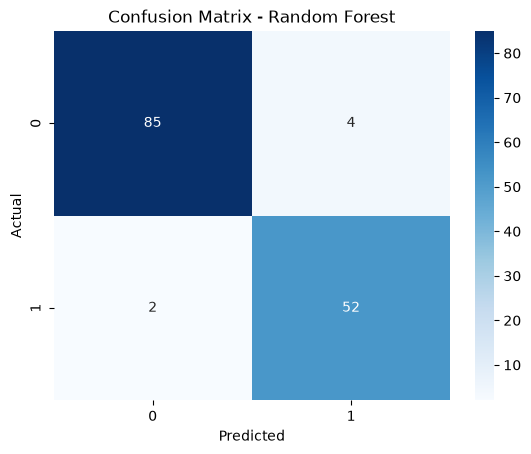

In [19]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(random_state=42)

model_rf.fit(X_train_scaled, y_train)

y_pred = model_rf.predict(X_test_scaled)

evaluate_model(y_pred, model_name="Random Forest")
plot_confusion_matrix(y_pred, model_name="Random Forest")

C:\Users\cecpc\AppData\Local\Temp\ipykernel_15344\2167789599.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importancias, palette='viridis')


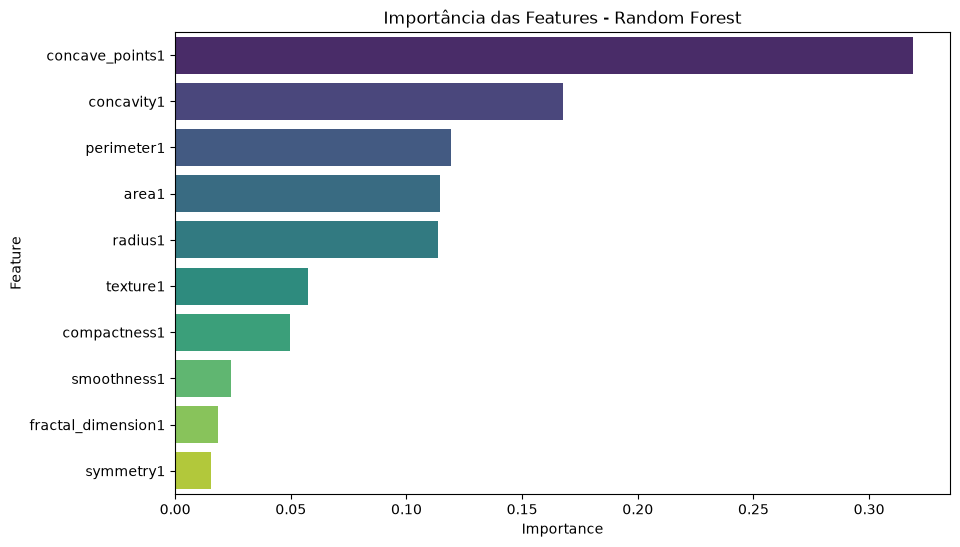

In [20]:
importancia_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

importancias = importancia_rf.sort_values(by='Importance', ascending=False)

# 4. Plotando o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importancias, palette='viridis')
plt.title('Importância das Features - Random Forest')
plt.show()

### Logistic Regression

Evaluating Logistic Regression:
Accuracy: 0.937
Precision: 0.909
Recall: 0.926
F1-Score: 0.917
ROC AUC Score: 0.935
Especificidade: 0.944


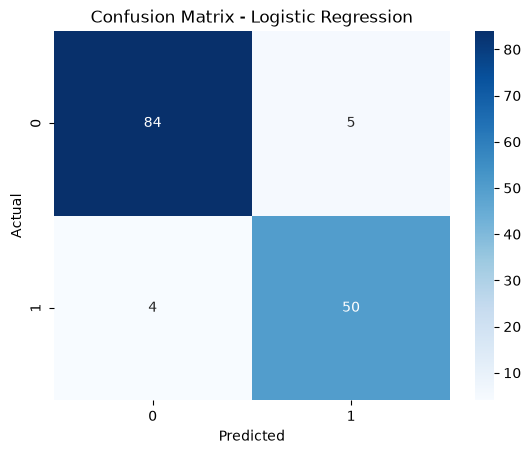

In [21]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(random_state=42)
model_lr.fit(X_train_scaled, y_train)

y_pred = model_lr.predict(X_test_scaled)

evaluate_model(y_pred, model_name="Logistic Regression")
plot_confusion_matrix(y_pred, model_name="Logistic Regression")

C:\Users\cecpc\AppData\Local\Temp\ipykernel_15344\3748138489.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importancias_lr, palette='viridis')


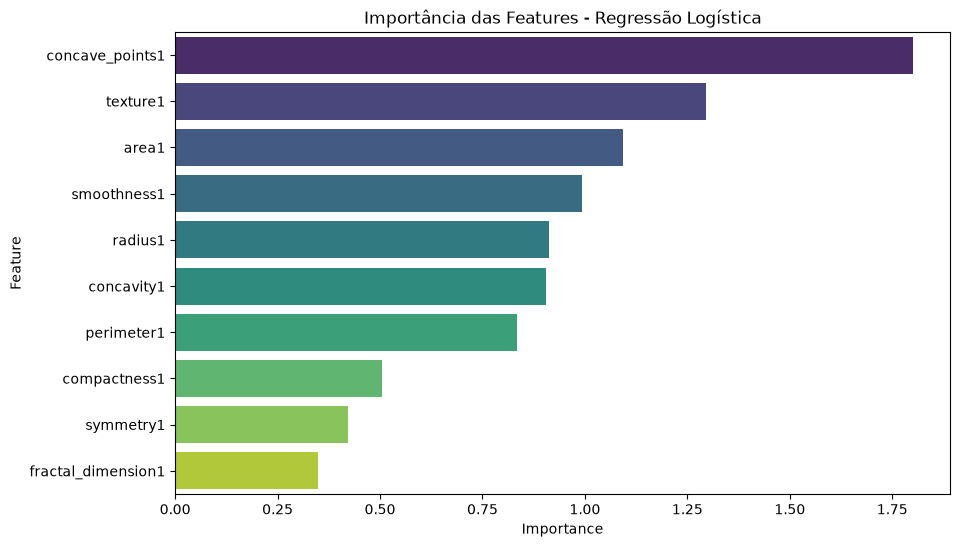

In [24]:
import numpy as np

importancias_lr = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': np.abs(model_lr.coef_[0]) 
})

importancias_lr = importancias_lr.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importancias_lr, palette='viridis')
plt.title('Importância das Features - Regressão Logística')
plt.show()

### Decision Tree

Evaluating Decision Tree:
Accuracy: 0.916
Precision: 0.889
Recall: 0.889
F1-Score: 0.889
ROC AUC Score: 0.911
Especificidade: 0.933


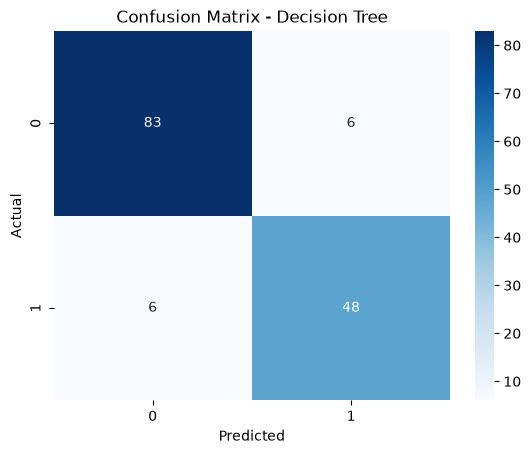

In [25]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(random_state=42, criterion='entropy')
model_dt.fit(X_train_scaled, y_train)

y_pred = model_dt.predict(X_test_scaled)

evaluate_model(y_pred, model_name="Decision Tree")
plot_confusion_matrix(y_pred, model_name="Decision Tree")

C:\Users\cecpc\AppData\Local\Temp\ipykernel_15344\3149272106.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importancia_dt, palette='viridis')


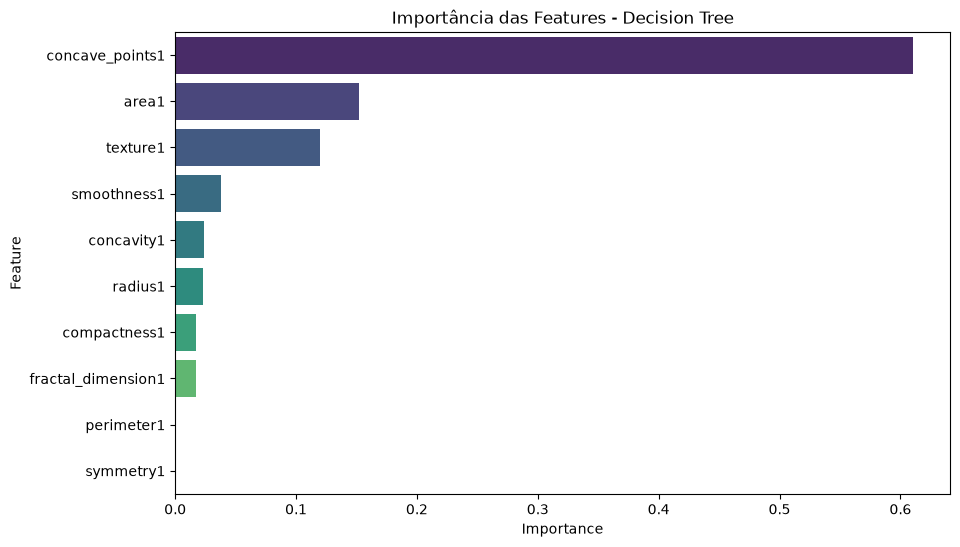

In [26]:
importancia_dt = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model_dt.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importancia_dt, palette='viridis')
plt.title('Importância das Features - Decision Tree')
plt.show()

### KNN

Evaluating KNN:
Accuracy: 0.944
Precision: 0.911
Recall: 0.944
F1-Score: 0.927
ROC AUC Score: 0.944
Especificidade: 0.944


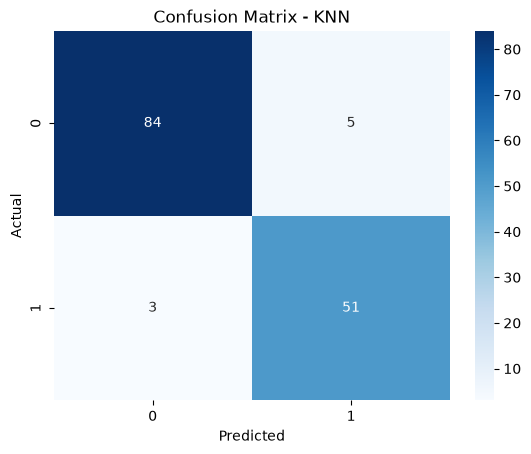

In [27]:
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier()

model_knn.fit(X_train_scaled, y_train)

y_pred = model_knn.predict(X_test_scaled)

evaluate_model(y_pred, model_name="KNN")
plot_confusion_matrix(y_pred, model_name="KNN")

C:\Users\cecpc\AppData\Local\Temp\ipykernel_15344\3701607095.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importancia_knn, palette='viridis')


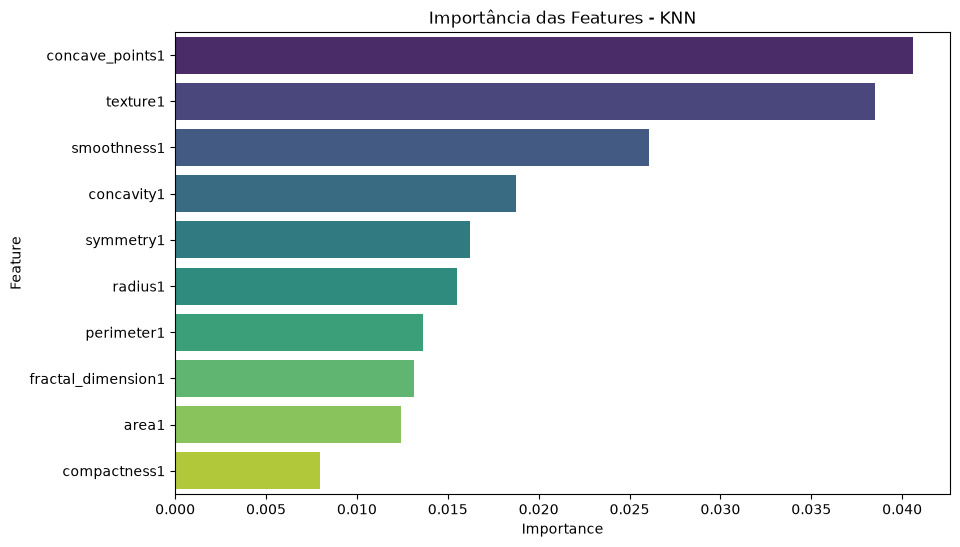

In [30]:
resultado = permutation_importance(model_knn, X_train_scaled, y_train, n_repeats=10, random_state=42)

importancia_knn = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': resultado.importances_mean
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importancia_knn, palette='viridis')
plt.title('Importância das Features - KNN')
plt.show()

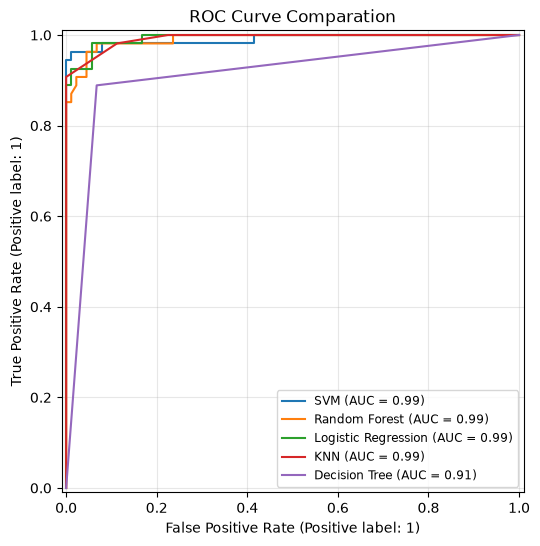

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(10, 6))

RocCurveDisplay.from_estimator(model_svm, X_test_scaled, y_test, ax=ax, name='SVM')
RocCurveDisplay.from_estimator(model_rf, X_test_scaled, y_test, ax=ax, name='Random Forest')
RocCurveDisplay.from_estimator(model_lr, X_test_scaled, y_test, ax=ax, name='Logistic Regression')
RocCurveDisplay.from_estimator(model_knn, X_test_scaled, y_test, ax=ax, name='KNN')
RocCurveDisplay.from_estimator(model_dt, X_test_scaled, y_test, ax=ax, name='Decision Tree')

plt.title('ROC Curve Comparation')
plt.legend(loc='lower right', fontsize='small')
plt.grid(alpha=0.3)

plt.show()

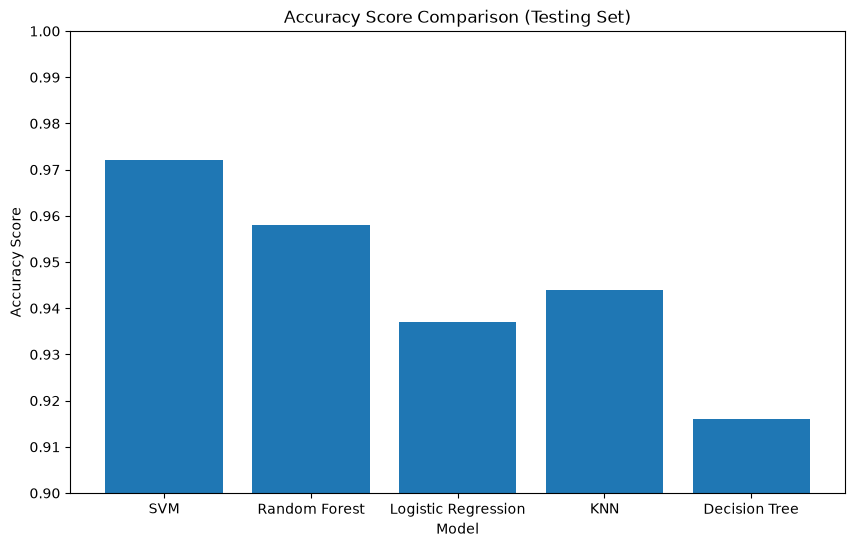

In [17]:
import numpy as np

accuracy_scores = {
    "SVM": accuracy_score(y_test, model_svm.predict(X_test_scaled)),
    "Random Forest": accuracy_score(y_test, model_rf.predict(X_test_scaled)),
    "Logistic Regression": accuracy_score(y_test, model_lr.predict(X_test_scaled)),
    "KNN": accuracy_score(y_test, model_knn.predict(X_test_scaled)),
    "Decision Tree": accuracy_score(y_test, model_dt.predict(X_test_scaled))
}

plt.figure(figsize=(10, 6))

plt.bar(accuracy_scores.keys(), accuracy_scores.values())
plt.xlabel('Model')
plt.ylabel('Accuracy Score')
plt.title('Accuracy Score Comparison (Testing Set)')
plt.ylim(0.90, 1.00)
plt.yticks(np.arange(0.90, 1.01, 0.01))
plt.show()

### XGBoost

Evaluating XGBoost:
Accuracy: 0.965
Precision: 0.930
Recall: 0.981
F1-Score: 0.955
ROC AUC Score: 0.968
Especificidade: 0.955


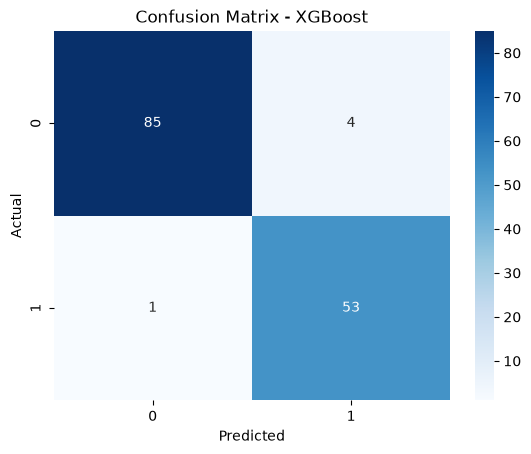

In [54]:
import xgboost as xgb

model_xgb = xgb.XGBClassifier(random_state=42)

model_xgb.fit(X_train_scaled, y_train)

y_pred = model_xgb.predict(X_test_scaled)
evaluate_model(y_pred, model_name="XGBoost")
plot_confusion_matrix(y_pred, model_name="XGBoost")

C:\Users\cecpc\AppData\Local\Temp\ipykernel_15344\364053064.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Feature', data=importancias_xgb, palette='viridis')


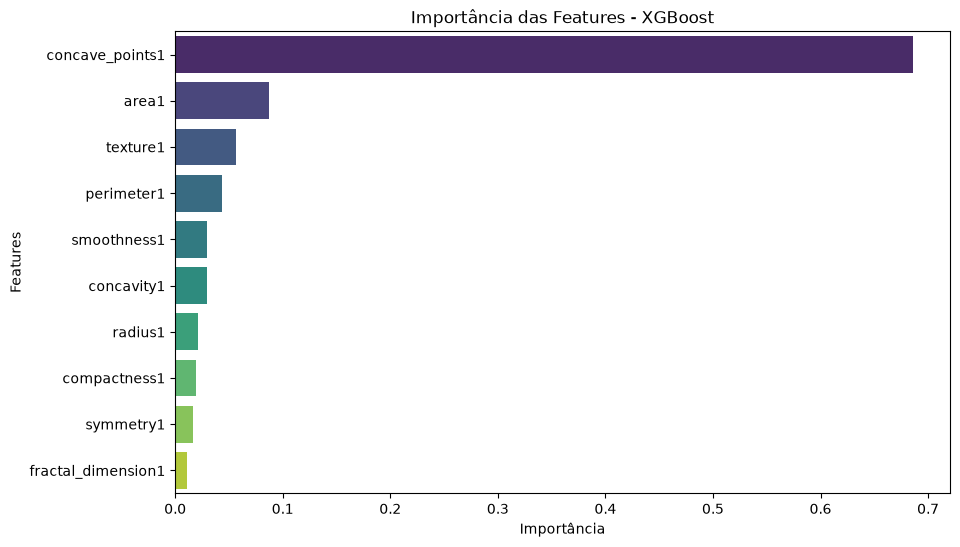

In [61]:
# 3. Plotando com a função nativa
importancias_xgb = pd.DataFrame({
    'Feature': X_train.columns, 
    'Importancia': model_xgb.feature_importances_
})

# 3. Ordene e pegue as 11 maiores
importancias_xgb = importancias_xgb.sort_values(by='Importancia', ascending=False).head(11)

# 4. Plote com Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Feature', data=importancias_xgb, palette='viridis')
plt.title('Importância das Features - XGBoost')
plt.xlabel('Importância')
plt.ylabel('Features')
plt.show()

### Light GBM

[LightGBM] [Info] Number of positive: 158, number of negative: 268
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000141 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1405
[LightGBM] [Info] Number of data points in the train set: 426, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.370892 -> initscore=-0.528392
[LightGBM] [Info] Start training from score -0.528392
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

c:\Repos\cancer-detection\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


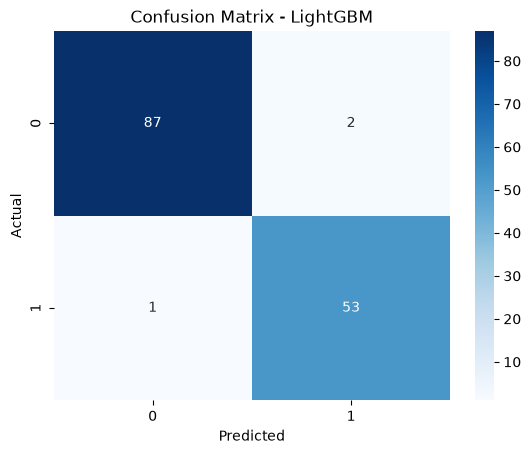

In [57]:
import lightgbm as lgb

model_lgb = lgb.LGBMClassifier(random_state=42)
model_lgb.fit(X_train_scaled, y_train)

y_pred = model_lgb.predict(X_test_scaled)

evaluate_model(y_pred, model_name="LightGBM")
plot_confusion_matrix(y_pred, model_name="LightGBM")

C:\Users\cecpc\AppData\Local\Temp\ipykernel_15344\1746589497.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Feature', data=importancias_lgb, palette='viridis')


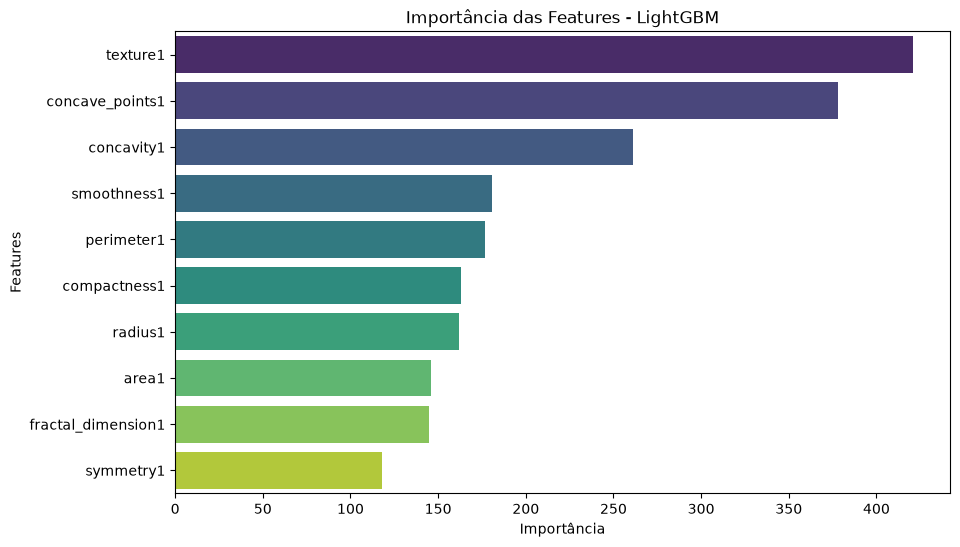

In [60]:

# 3. Plotando com a função nativa
# 3. Plotando com a função nativa
importancias_lgb = pd.DataFrame({
    'Feature': X_train.columns, 
    'Importancia': model_lgb.feature_importances_
})

# 3. Ordene e pegue as 11 maiores
importancias_lgb = importancias_lgb.sort_values(by='Importancia', ascending=False).head(11)

# 4. Plote com Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Feature', data=importancias_lgb, palette='viridis')
plt.title('Importância das Features - LightGBM')
plt.xlabel('Importância')
plt.ylabel('Features')
plt.show()

### CatBoost

Evaluating CatBoost:
Accuracy: 0.965
Precision: 0.945
Recall: 0.963
F1-Score: 0.954
ROC AUC Score: 0.965
Especificidade: 0.966


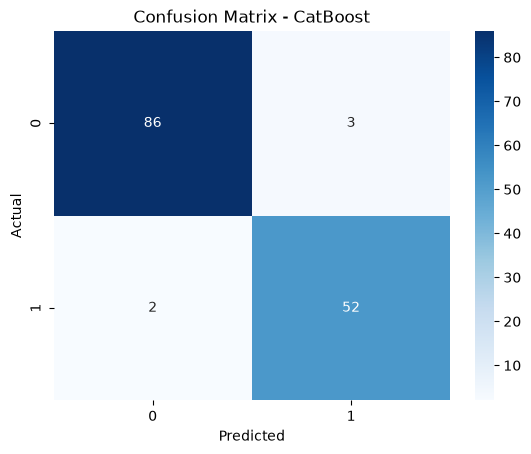

In [52]:
from catboost import CatBoostClassifier

model_cat = CatBoostClassifier(random_seed=42, verbose=0)

model_cat.fit(X_train_scaled, y_train)

y_pred = model_cat.predict(X_test_scaled)

evaluate_model(y_pred, model_name="CatBoost")
plot_confusion_matrix(y_pred, model_name="CatBoost")

C:\Users\cecpc\AppData\Local\Temp\ipykernel_15344\2590758365.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importancia_cat, palette='viridis')


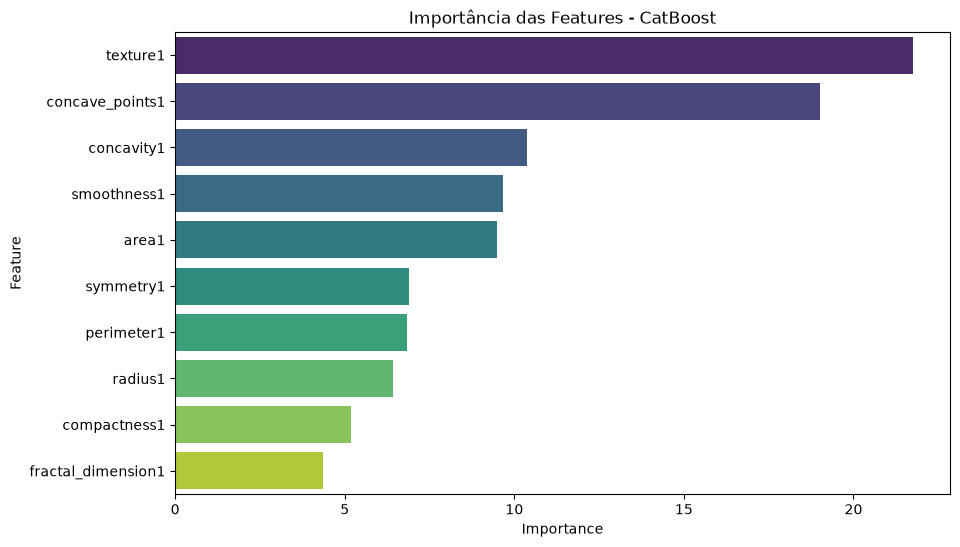

In [53]:
importancia_cat = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model_cat.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importancia_cat, palette='viridis')
plt.title('Importância das Features - CatBoost')
plt.show()

## Evaluation

c:\Repos\cancer-detection\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


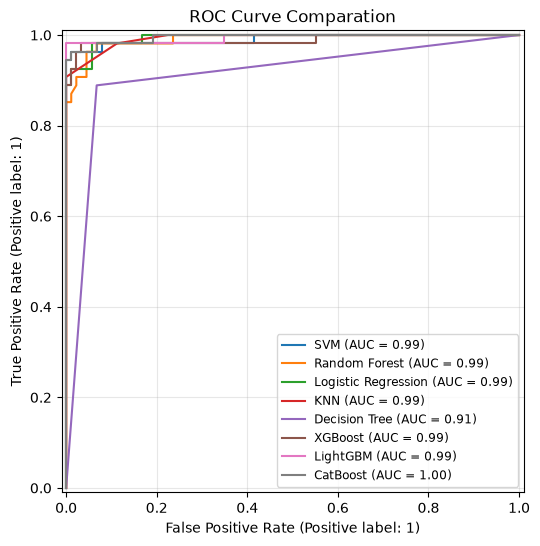

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

RocCurveDisplay.from_estimator(model_svm, X_test_scaled, y_test, ax=ax, name='SVM')
RocCurveDisplay.from_estimator(model_rf, X_test_scaled, y_test, ax=ax, name='Random Forest')
RocCurveDisplay.from_estimator(model_lr, X_test_scaled, y_test, ax=ax, name='Logistic Regression')
RocCurveDisplay.from_estimator(model_knn, X_test_scaled, y_test, ax=ax, name='KNN')
RocCurveDisplay.from_estimator(model_dt, X_test_scaled, y_test, ax=ax, name='Decision Tree')
RocCurveDisplay.from_estimator(model_xgb, X_test_scaled, y_test, ax=ax, name='XGBoost')
RocCurveDisplay.from_estimator(model_lgb, X_test_scaled, y_test, ax=ax, name='LightGBM')
RocCurveDisplay.from_estimator(model_cat, X_test_scaled, y_test, ax=ax, name='CatBoost')

plt.title('ROC Curve Comparation')
plt.legend(loc='lower right', fontsize='small')
plt.grid(alpha=0.3)

plt.show()

c:\Repos\cancer-detection\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


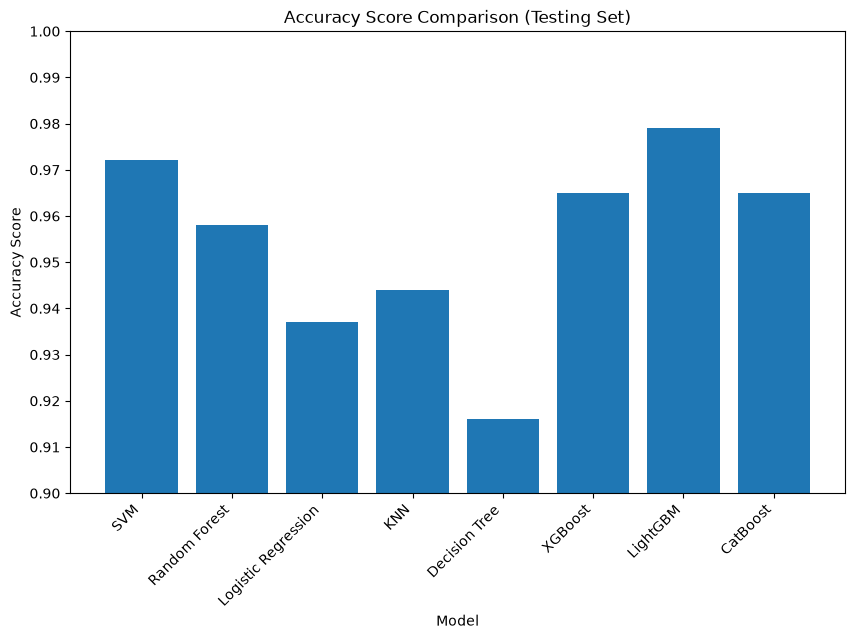

In [22]:
import numpy as np

accuracy_scores = {
    "SVM": accuracy_score(y_test, model_svm.predict(X_test_scaled)),
    "Random Forest": accuracy_score(y_test, model_rf.predict(X_test_scaled)),
    "Logistic Regression": accuracy_score(y_test, model_lr.predict(X_test_scaled)),
    "KNN": accuracy_score(y_test, model_knn.predict(X_test_scaled)),
    "Decision Tree": accuracy_score(y_test, model_dt.predict(X_test_scaled)),
    "XGBoost": accuracy_score(y_test, model_xgb.predict(X_test_scaled)),
    "LightGBM": accuracy_score(y_test, model_lgb.predict(X_test_scaled)),
    "CatBoost": accuracy_score(y_test, model_cat.predict(X_test_scaled))
}

plt.figure(figsize=(10, 6))

plt.bar(accuracy_scores.keys(), accuracy_scores.values())
plt.xlabel('Model')
plt.ylabel('Accuracy Score')
plt.title('Accuracy Score Comparison (Testing Set)')
plt.ylim(0.90, 1.00)
plt.yticks(np.arange(0.90, 1.01, 0.01))
plt.xticks(rotation=45, ha='right')
plt.show()